In [46]:
import os
import cartopy
import numpy as np
import xarray as xr
os.chdir("/home/philbou/projects/def-rfajber/philbou")
from wva_data.experiment.experiment_loader import ExperimentLoader, Diagnostic
from wva_data.experiment.figure_helper import get_pot_temp_np, tropopause_height, plot_2d

from datetime import datetime
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy
cartopy.config['pre_existing_data_dir'] = '/home/philbou/miniconda3/envs/pro_env/share/cartopy'
cartopy.config['data_dir'] = '/home/philbou/miniconda3/envs/pro_env/share/cartopy'

WVA_EXP = "/home/philbou/projects/def-rfajber/philbou/wva_exp"
WVA_DATA = "/home/philbou/projects/def-rfajber/philbou/wva_data"
NOTEBOOKS = "/home/philbou/projects/def-rfajber/philbou/wva_data/notebooks"
FIGURES = "/home/philbou/projects/def-rfajber/philbou/wva_data/figures/wva_paper"
SECONDSTODAYS = 1/(24*3600)

In [22]:
exp_0 = ExperimentLoader("RT42_sst_0_bucket")

In [23]:
exp_0.load_diagnostic("sphum", False)
exp_0.load_diagnostic("sphum", True)
exp_0.load_diagnostic("temp", True)
exp_0.load_diagnostic("ps", True,coord="_")
exp_0.load_diagnostic("phalf", True,coord="_")
exp_0.load_diagnostic("rh", True)
exp_0.load_diagnostic("dt_sink", True)
exp_0.load_diagnostic("ucomp", False)
exp_0.load_diagnostic("vcomp", False)
exp_0.load_diagnostic("vcomp", True)


exp_0.__setattr__("_lat", exp_0.sphum_monthly.data.lat)
exp_0.__setattr__("_lon", exp_0.sphum_monthly.data.lon)
exp_0.__setattr__("_time", exp_0.sphum_monthly.data.time)
exp_0.__setattr__("_pfull", exp_0.sphum_monthly.data.pfull)

pot_temp_0_np = get_pot_temp_np(exp_0.temp_monthly.data.values, exp_0._pfull.values, exp_0._ps_monthly.data.values)
potential_temperature_0 = xr.DataArray(pot_temp_0_np, coords=exp_0.temp_monthly.data.coords, dims=exp_0.temp_monthly.data.dims)
exp_0.__setattr__("_potential_temperature_monthly", Diagnostic("potential_temperature_monthly", potential_temperature_0))

tropopause_height_0_np = tropopause_height(exp_0._pfull.values,exp_0._phalf_monthly.data.values,exp_0.temp_monthly.time.values,exp_0._lat.values)
tropopause_height_0 = xr.DataArray(tropopause_height_0_np, coords=exp_0._ps_monthly.time_zonal.coords, dims=exp_0._ps_monthly.time_zonal.dims)
exp_0.__setattr__("_tropopause_height_monthly",Diagnostic("tropopause_height_monthly", tropopause_height_0))

mask = exp_0._pfull > 1e-2*exp_0._ps_monthly.time_zonal
height_mask = mask.broadcast_like(exp_0.sphum_monthly.time)
exp_0.__setattr__("_height_mask", Diagnostic("height_mask", height_mask))

exp_0.apply_height_mask()


In [58]:
def plot_vertical_profile(ax, diag, exp ,cmap = "YlGnBu", level_space=25,
                          lnP = False, thetac="",extend = "max",
                          pmax=1000,pmin=100,cbar_label = "",title = ""):
    """Plots any diagnostics in its vertical profile """

    if lnP: 
        ax.set_yscale("log")
    
    cs=ax.contourf(exp._lat, exp._pfull, diag,cmap=cmap,
                    extend=extend,levels = level_space)
        
    cbar = plt.colorbar(cs,shrink=0.8,orientation='vertical',pad=0.01)
    cbar.ax.tick_params(labelsize=30)
    cbar.set_label(cbar_label, fontsize=30)
    
    ax.set_xlabel("Latitude [deg]", fontsize = 30)
    ax.set_ylabel("Pressure [hPa]", fontsize = 30)
    ax.tick_params(axis='x', labelsize=24)  # Change font size for x-axis tick labels
    ax.tick_params(axis='y', labelsize=24)
    ax.set_ylim(pmax,pmin)
    ax.set_title(title, fontsize=40,pad=20)
    return cbar

def plot_potential_temperature(ax, exp, color = "Black", level_space=25):
    """Plots potential temperature in its vertical profile """
    cs=ax.contour(exp._lat, exp._pfull, exp._potential_temperature_monthly.time_zonal.values,colors = color,
                    extend="max",levels = level_space)
        
    cbar = plt.clabel(cs,inline=True,fmt='%1.0f', fontsize=25)
    return cbar

**Figure 1:** 

Time and zonal averages of (A) specific humidity, [q], (B) relative humidity, [RH],
(C) the negative contribution of the moisture tendency from condensation and convection,
[S−], (D) the mean meridional moisture transport, [v · q], (E) the transient eddy meridional
moisture transport, [v′q′], and (F) the eddy kinetic energy, [EKE] = [(u′2 + v′2)/2]. The
white contours indicate the isentropes, and the pink dashed line indicates the tropopause
height, defined as the level where the atmospheric lapse rate drops below 2K · km−1.

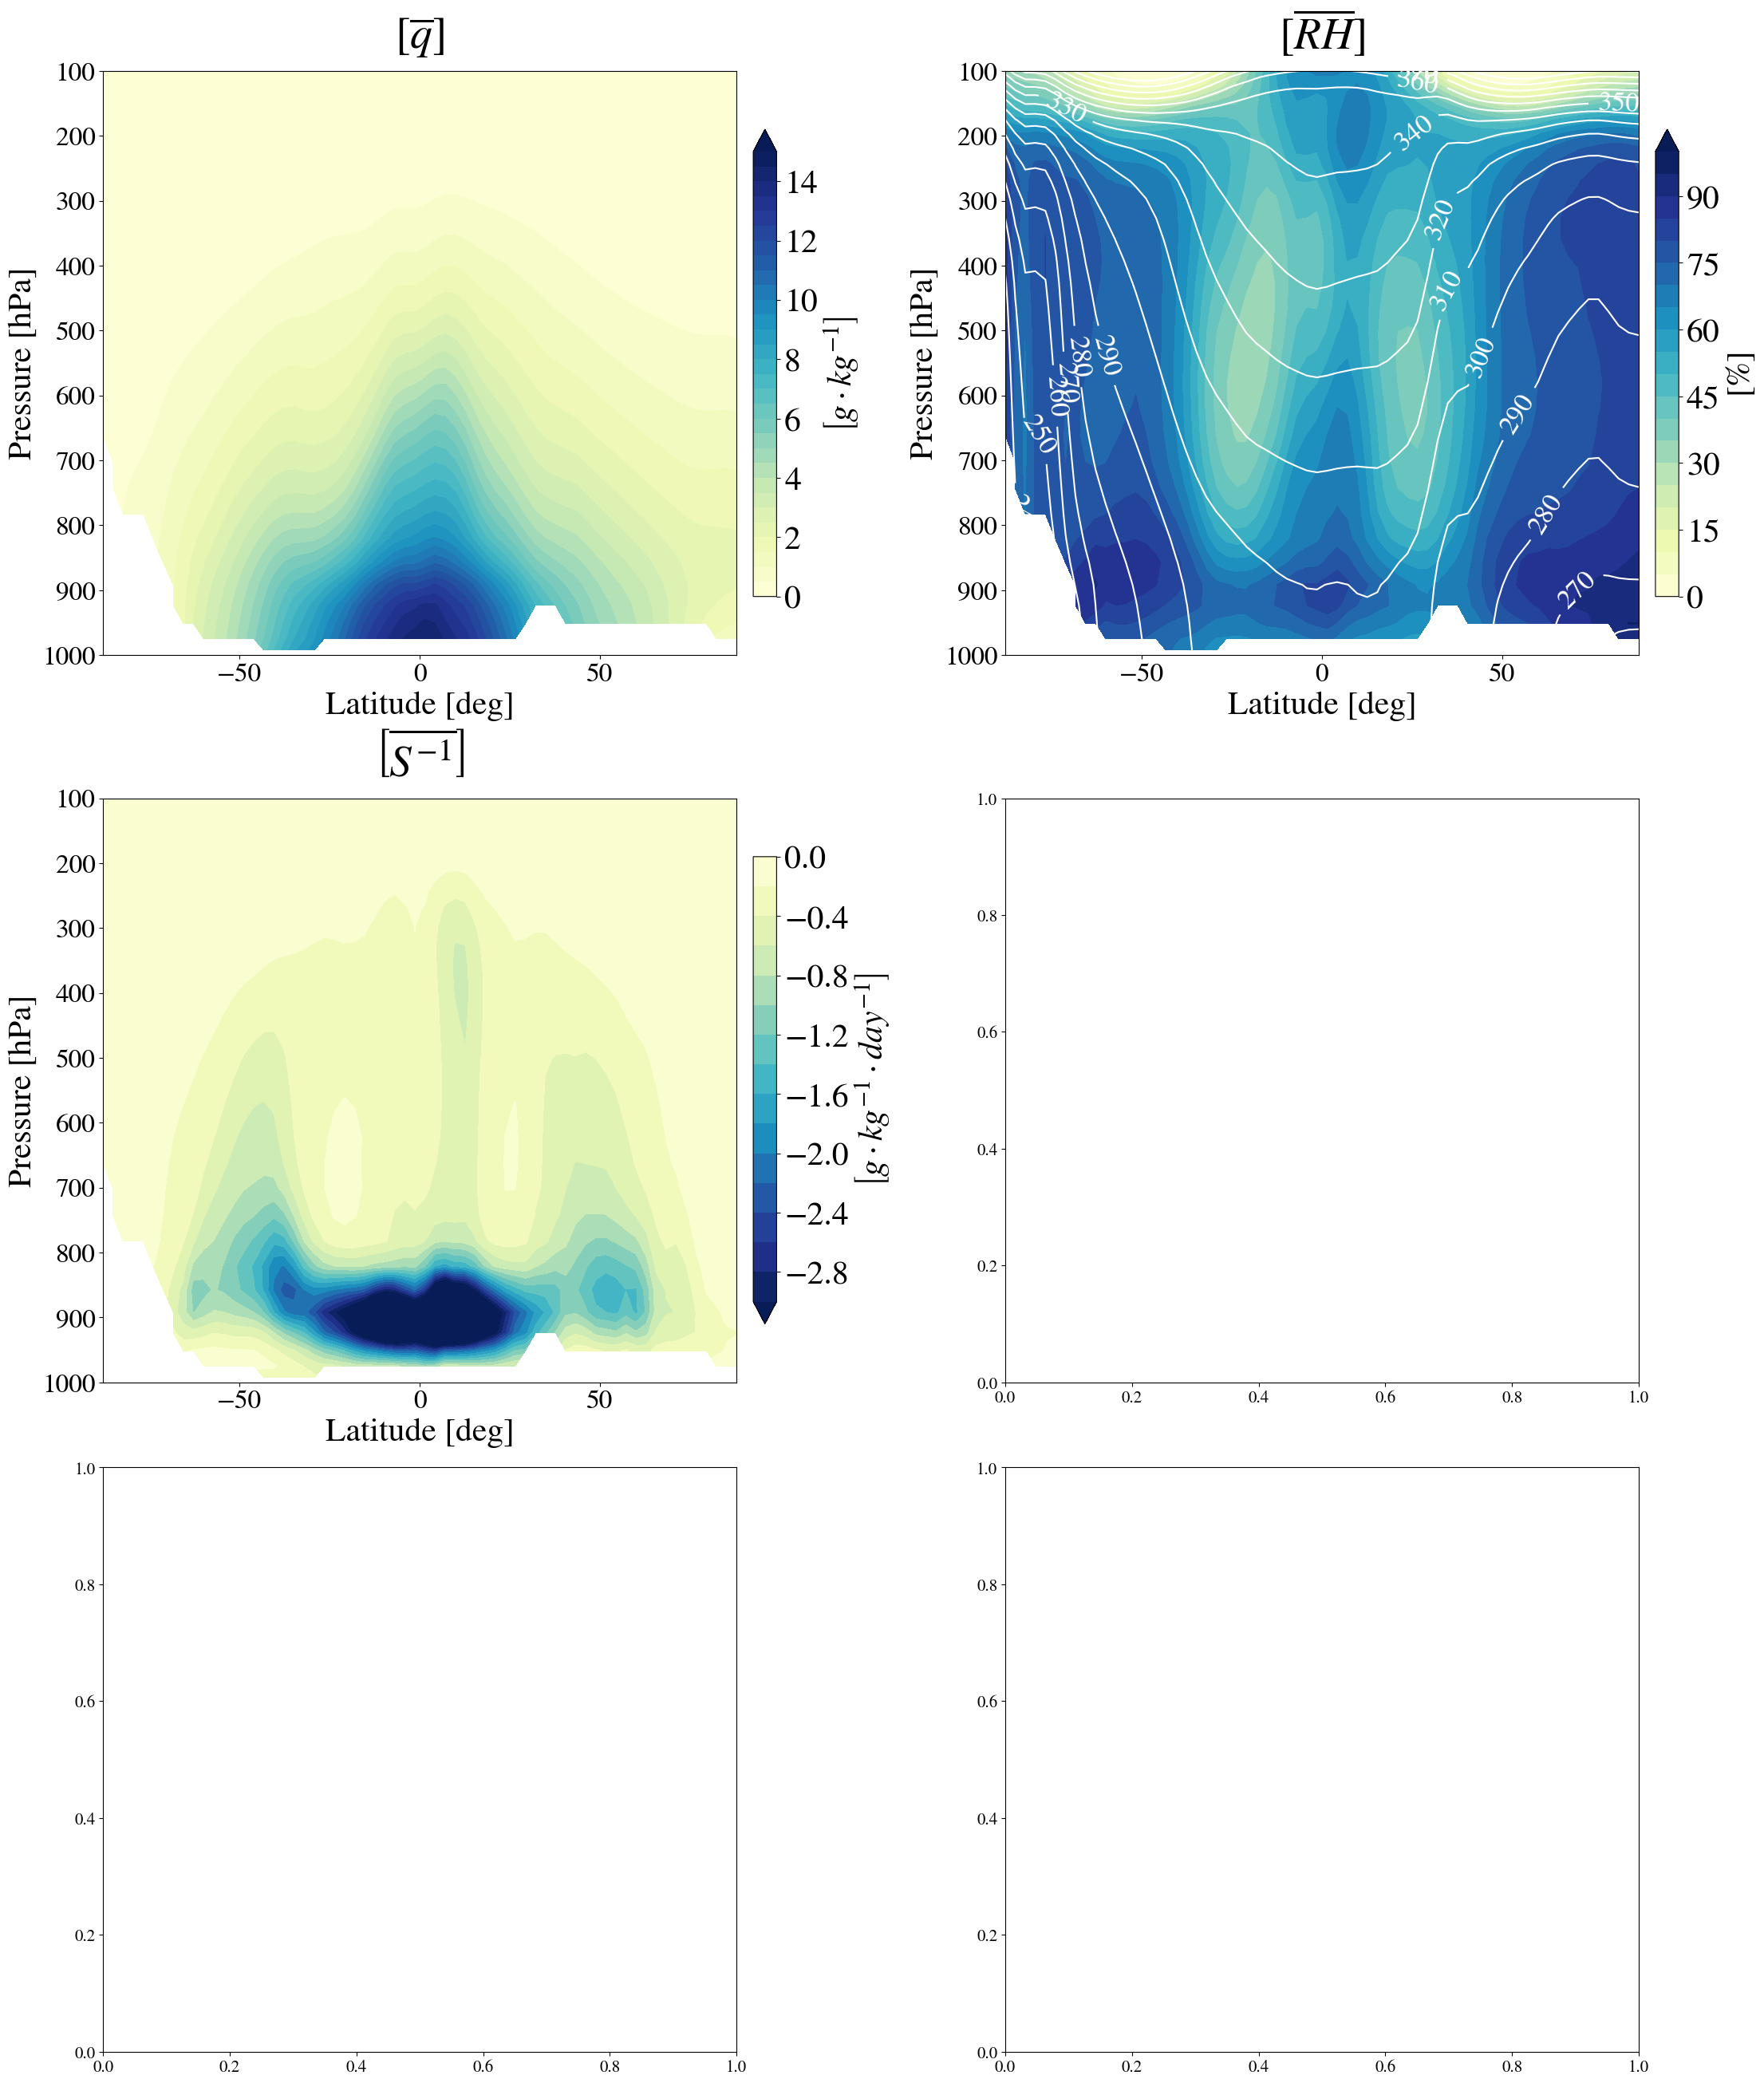

In [61]:
fig, ax = plt.subplots(3,2,figsize = (22,26),constrained_layout=True)
ax_sphum = ax[0,0]
cbar = plot_vertical_profile(ax_sphum, 1e3* exp_0.sphum_monthly.time_zonal.values, 
                             exp_0, cmap = "YlGnBu", level_space=np.linspace(0,15,31), 
                             lnP = False, title="$\\left[\\overline{q}\\right]$", cbar_label = "$\\left[g\\cdot kg^{-1}\\right]$")

ax_rh = ax[0,1]
cbar = plot_vertical_profile(ax_rh, exp_0.rh_monthly.time_zonal.values, 
                             exp_0, cmap = "YlGnBu", level_space=np.linspace(0,100,21), 
                             lnP = False,title = "$\\left[\\overline{RH}\\right]$",cbar_label = "$\\left[\\%\\right]$")
plot_potential_temperature(ax_rh, exp_0, color = "w", level_space=np.linspace(200,400,21))

ax_sink = ax[1,0]
cbar = plot_vertical_profile(ax_sink, (1e3/SECONDSTODAYS)*exp_0.dt_sink_monthly.time_zonal.values, 
                             exp_0, cmap = "YlGnBu_r", level_space=np.linspace(-3,0,16),
                             extend = "min", title = "$\\left[\\overline{S^{-1}}\\right]$",cbar_label = "$\\left[g \\cdot kg^{-1} \\cdot day^{-1}\\right]$")

AttributeError: 'ExperimentLoader' object has no attribute 'lat'

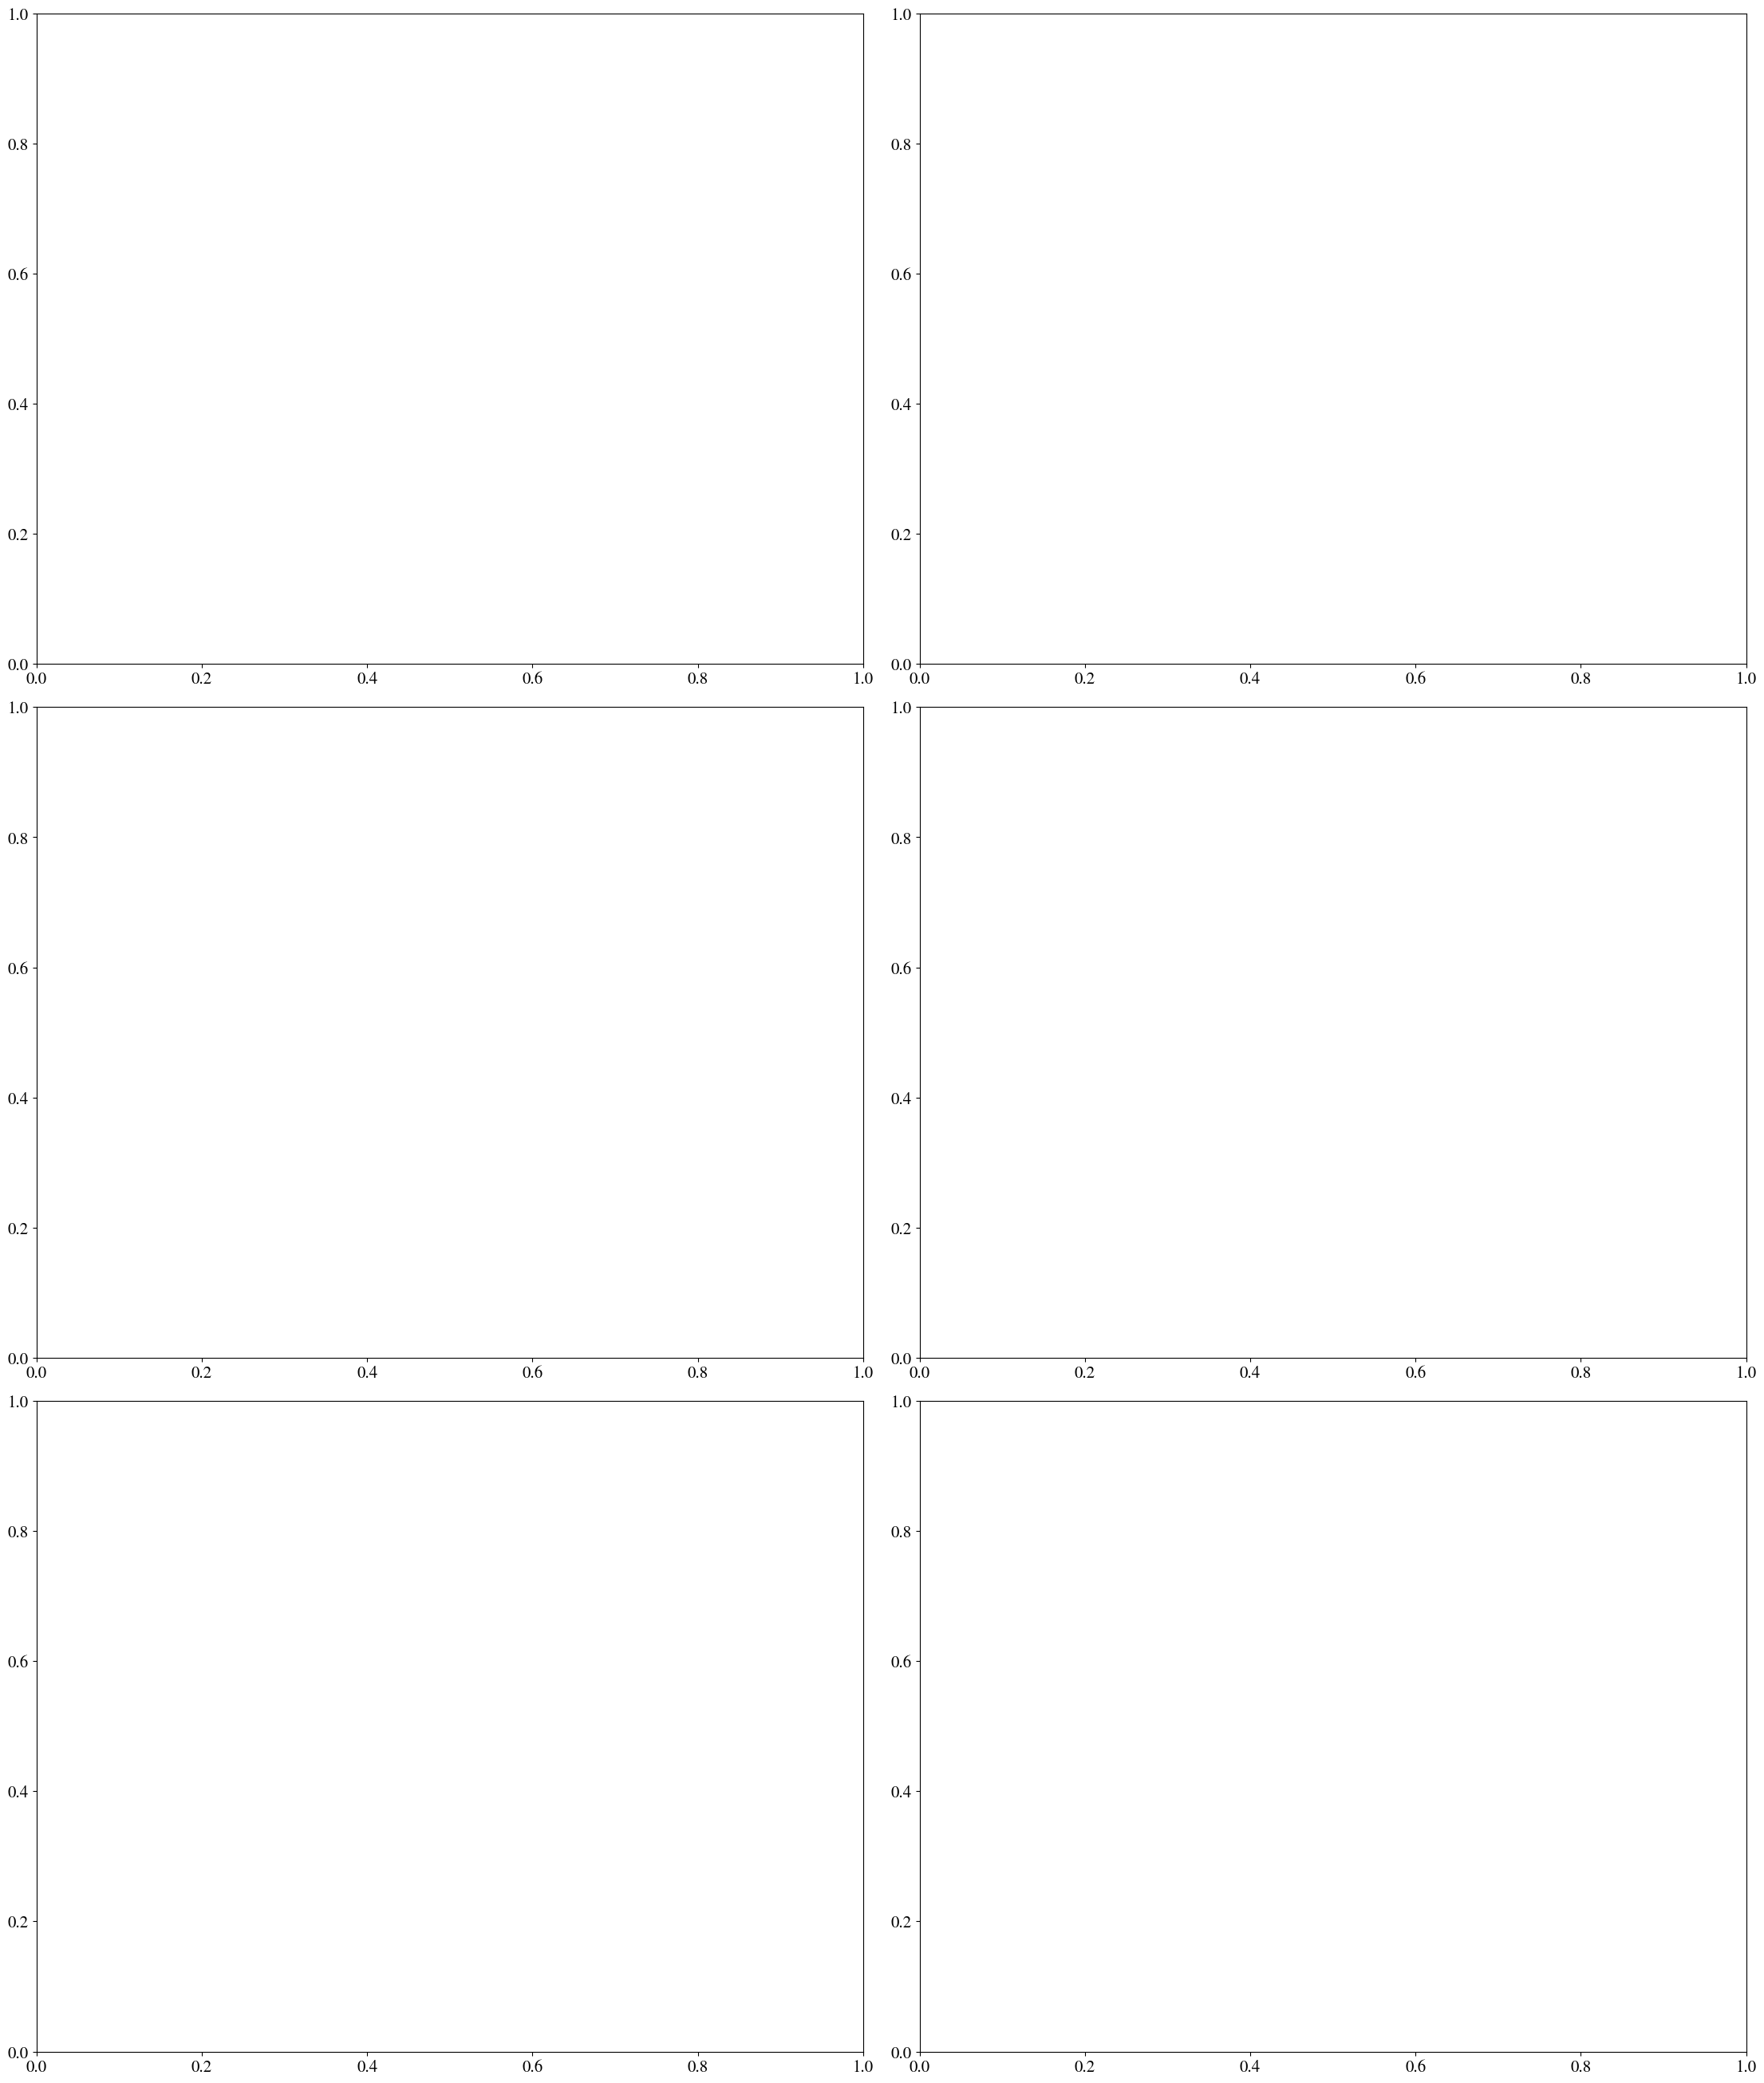

In [60]:
fig, ax = plt.subplots(3,2,figsize = (22,26),constrained_layout=True)
ax_sphum = ax[0,0]

fig_,ax_sphum,cbar = plot_2d(exp_0.sphum_monthly.time_zonal,exp_0.lat,exp_0.lon,ax_sphum,cmap = "YlGnBu",level_space=np.linspace(0,15,31),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "max")

ax_sink.set_title("$[\\overline{q}]$\n       (A)", pad=20, fontsize=30)

ax_sink.plot(lat,zonal_ps/100)

cbar.set_label("$g\\cdot kg^{-1}$",fontsize = 25,labelpad = 5)

ax_sink = ax[0,1]
fig_,ax_sink,cbar = dps.plot_age_moments_vertical_profile(100,rh0 * (24*60**2),1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=26,min_val = 0,ext = "max",theta = False)
ax_sink.set_title("$[\\overline{RH}]$ \n       (B)", pad=20, fontsize=25)
isentropic_levels = np.arange(250, 390, 20)
cs=ax_sink.contour(lat, pfull, pot_temp_zonal,colors="white",levels = isentropic_levels)
plt.clabel(cs, inline=True, fontsize=14)  
cbar.set_label("$\\%$",fontsize = 25,labelpad = 5)

ax_sink = ax[1,0]
fig_,ax_sink,cbar = dps.plot_age_moments_vertical_profile(0,1e3*sink0 * (24*60**2)**2,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu_r",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=16,min_val = -3,ext = "min",theta = False)
ax_sink.set_title("$[\\overline{S^-}]$ \n       (C)",pad = 20,fontsize = 30)
ax_sink.set_ylabel(" ")
cbar.set_label("$g\\cdot kg^{-1}\\cdot $day$^{-1}$",fontsize = 25,labelpad = 5)
    
ax_v = ax[1,1]

from matplotlib.colors import SymLogNorm

cbar = dps.plot_vertical_profile(1e3*np.mean(vq_time0,axis = 2),lat,pfull,ax_v,"Spectral_r",mask,level_space=np.linspace(-12.5,12.5,25),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_v.set_title("$[\\overline{v}\\cdot\\overline{q}]$ \n     (D)",fontsize = 30,pad = 20)
ax_v.set_xlabel(" ")
ax_v.set_ylabel(" ")
cbar.set_label("$g \\cdot kg^{-1} \\cdot m \\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_vp = ax[2,0]
# Define dense log-like contour levels
linthresh = 1e-6
vmax = 12.5
vmin = -vmax

# Log-spaced levels
n_levels = 26
log_pos = np.logspace(np.log10(linthresh), np.log10(vmax), n_levels//2)
log_neg = -log_pos[::-1]
levels = np.concatenate([log_neg, [0], log_pos])

# Symmetric log normalization
norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)

cbar = dps.plot_vertical_profile(1e3*np.mean(vqprime0_time,axis = 2),lat,pfull,ax_vp,"Spectral_r",mask,norm=False,level_space = np.linspace(-12.5,12.5,25),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_vp.set_title("$[\\overline{v'q'}]$ \n (E)",fontsize = 30,pad = 20)

cbar.set_label("$g \\cdot kg^{-1} \\cdot m \\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_ed = ax[2,1]
cbar = dps.plot_vertical_profile(0.1*np.mean(eddykin0_time,axis = 2),lat,pfull,ax_ed,bottom_half_cmap,mask,level_space=np.linspace(0,25,26),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "max")

ax_ed.set_title("$[\\overline{EKE}]$ \n (F)",fontsize = 30,pad = 20)
cbar.set_label("$10\\cdot J \\cdot kg^{-1}$",fontsize = 25,labelpad = 5)

ax_ed.set_ylabel(" ")





for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(975,75)
        ax[i,j].set_xlabel("Latitude", fontsize = 24)
        ax[i,j].set_ylabel("Pressure [hPa]", fontsize = 24)
        ax[i,j].tick_params(axis='x', labelsize=18)  # Change font size for x-axis tick labels
        ax[i,j].tick_params(axis='y', labelsize=18)

ax[0,1].plot(lat,trop_h_0,color = "hotpink",linewidth = 3,linestyle = "dashed")
ax[2,1].plot(lat,trop_h_0,color = "hotpink",linewidth = 3,linestyle = "dashed")
      
#fig.suptitle("Control Experiment",fontsize = 35,y = 0.95)    
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
fig.savefig(f"{path_cur}/circulation_vert.png",dpi = 250 )